# Job Market Intelligence: Exploratory Analysis
**Data:** 1,499 US job listings across 6 DA/DS roles, sourced from Adzuna API.  
**Goal:** Understand the market in-demand skills, salary ranges, and remote opportunities.

## 0. Setup

In [18]:
import os
import sys
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pg8000
from dotenv import load_dotenv

# Load .env from project root
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))
load_dotenv('../.env')  # works when run from notebooks/

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Setup complete')

Setup complete


In [19]:
conn = pg8000.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    port=int(os.getenv('DB_PORT', 5433)),
    database=os.getenv('DB_NAME', 'jobmarket'),
    user=os.getenv('DB_USER', 'jobmarket'),
    password=os.getenv('DB_PASSWORD', 'jobmarket'),
)

df = pd.read_sql(
    'SELECT * FROM job_listings',
    conn,
)
conn.close()

print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Loaded 1,499 rows, 16 columns


C:\Users\faafm\AppData\Local\Temp\ipykernel_4368\1628145465.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,id,title,company,location_display,location_area,description,category,contract_type,contract_time,salary_min,salary_max,salary_is_predicted,redirect_url,search_role,created,fetched_at
0,5692133257,Data Analyst II,NES Fircroft,"Spring, Harris County",Spring,Job Title: Data Analyst II (Administrative / T...,IT Jobs,contract,full_time,103726.10,103726.10,1,https://www.adzuna.com/land/ad/5692133257?se=R...,data analyst,2026-04-07 10:31:20,2026-04-08 23:05:27.205076
1,5692167474,Well Delivery Data Analyst,NES Fircroft,"Spring, Harris County",Spring,Drilling and Completions Well Delivery Data An...,IT Jobs,contract,full_time,142493.28,142493.28,1,https://www.adzuna.com/land/ad/5692167474?se=R...,data analyst,2026-04-07 11:33:12,2026-04-08 23:05:27.214304
2,5691567029,Data Analyst,Angelo State University,"San Angelo, Tom Green County",San Angelo,*Job Title:*Data Analyst *Position Number:*977...,IT Jobs,None,None,54364.01,54364.01,1,https://www.adzuna.com/land/ad/5691567029?se=R...,data analyst,2026-04-06 17:56:58,2026-04-08 23:05:27.222754


## 1. Dataset Overview

In [20]:
print('=== Basic Stats ===')
print(f'Total listings:        {len(df):,}')
print(f'Unique companies:      {df["company"].nunique():,}')
print(f'Listings with salary:  {df["salary_min"].notna().sum():,} ({df["salary_min"].notna().mean():.1%})')
print(f'Date range:            {df["created"].min()} → {df["created"].max()}')
print()
print('=== Listings per Role ===')
print(df['search_role'].value_counts().to_string())

=== Basic Stats ===
Total listings:        1,499
Unique companies:      361
Listings with salary:  1,499 (100.0%)
Date range:            2023-09-23 15:01:18 → 2026-04-08 18:57:21

=== Listings per Role ===
search_role
data analyst                 250
data scientist               250
data engineer                250
business analyst             250
machine learning engineer    250
analytics engineer           249


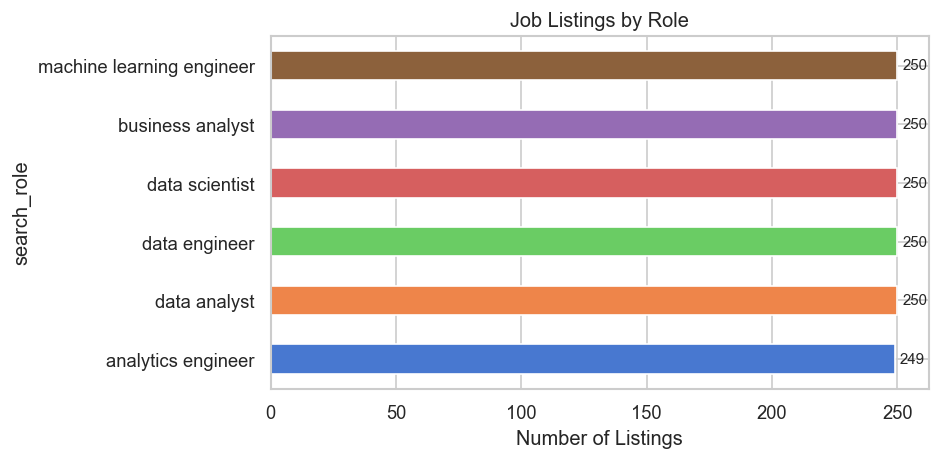

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
role_counts = df['search_role'].value_counts().sort_values()
role_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(role_counts)))
ax.set_xlabel('Number of Listings')
ax.set_title('Job Listings by Role')
for i, v in enumerate(role_counts):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Skills Analysis
Extracting technology/tool mentions from job descriptions.

In [22]:
# Skills to look for — grouped by category
SKILLS = {
    # Languages
    'Python': r'\bpython\b',
    'SQL': r'\bsql\b',
    'R': r'\b(?:r programming|r language|\br\b)',
    'Scala': r'\bscala\b',
    'Java': r'\bjava\b',
    'Julia': r'\bjulia\b',

    # BI & Visualization
    'Tableau': r'\btableau\b',
    'Power BI': r'\bpower\s*bi\b',
    'Looker': r'\blooker\b',
    'Excel': r'\bexcel\b',
    'Matplotlib': r'\bmatplotlib\b',
    'Plotly': r'\bplotly\b',

    # ML / AI
    'Machine Learning': r'\bmachine\s+learning\b',
    'Deep Learning': r'\bdeep\s+learning\b',
    'NLP': r'\bnlp\b|\bnatural\s+language\s+processing\b',
    'LLM': r'\bllm\b|\blarge\s+language\s+model\b',
    'TensorFlow': r'\btensorflow\b',
    'PyTorch': r'\bpytorch\b',
    'scikit-learn': r'\bscikit[- ]?learn\b|\bsklearn\b',

    # Data & Cloud
    'Spark': r'\bapache\s+spark\b|\bpyspark\b|\bspark\b',
    'Airflow': r'\bairflow\b',
    'dbt': r'\bdbt\b',
    'Kafka': r'\bkafka\b',
    'AWS': r'\baws\b|\bamazon\s+web\s+services\b',
    'Azure': r'\bazure\b',
    'GCP': r'\bgcp\b|\bgoogle\s+cloud\b',
    'Snowflake': r'\bsnowflake\b',
    'Databricks': r'\bdatabricks\b',
    'BigQuery': r'\bbigquery\b',
    'Redshift': r'\bredshift\b',
    
    # General
    'Git': r'\bgit\b',
    'Docker': r'\bdocker\b',
    'Kubernetes': r'\bkubernetes\b|\bk8s\b',
    'Statistics': r'\bstatistics\b|\bstatistical\b',
    'Pandas': r'\bpandas\b',
    'NumPy': r'\bnumpy\b',
}

desc = df['description'].fillna('').str.lower()

skill_counts = {}
for skill, pattern in SKILLS.items():
    matches = desc.str.contains(pattern, regex=True)
    skill_counts[skill] = matches.sum()

skills_df = pd.Series(skill_counts).sort_values(ascending=False)
skills_pct = (skills_df / len(df) * 100).round(1)

print('Top 15 skills by % of job listings:')
print(skills_pct.head(15).to_string())

Top 15 skills by % of job listings:
Machine Learning    10.7
SQL                  6.5
Excel                3.5
AWS                  3.3
Python               3.2
Statistics           3.0
R                    2.6
GCP                  1.9
Snowflake            1.5
Power BI             0.7
dbt                  0.6
Tableau              0.6
Databricks           0.5
Azure                0.5
Spark                0.4


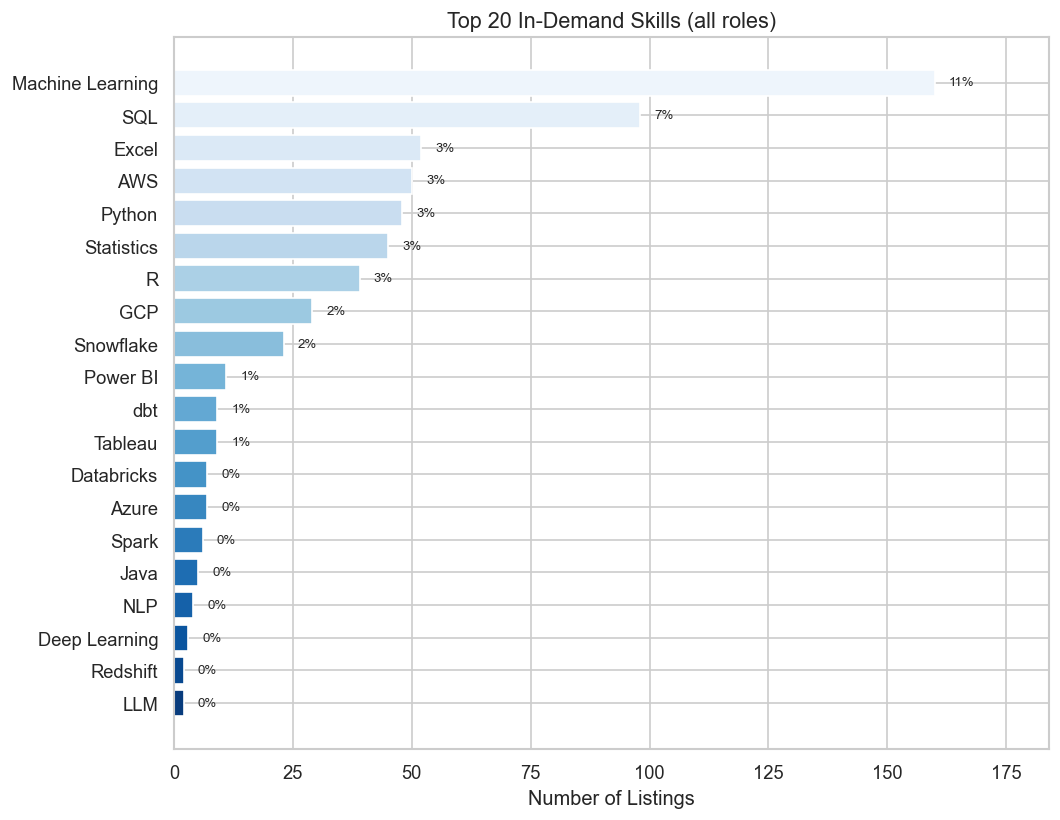

In [23]:
top_skills = skills_df.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('Blues_r', len(top_skills))
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1], color=colors)

for bar, val in zip(bars, top_skills.values[::-1]):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}%', va='center', fontsize=8)

ax.set_xlabel('Number of Listings')
ax.set_title('Top 20 In-Demand Skills (all roles)', fontsize=13)
ax.set_xlim(0, top_skills.max() * 1.15)
plt.tight_layout()
plt.show()

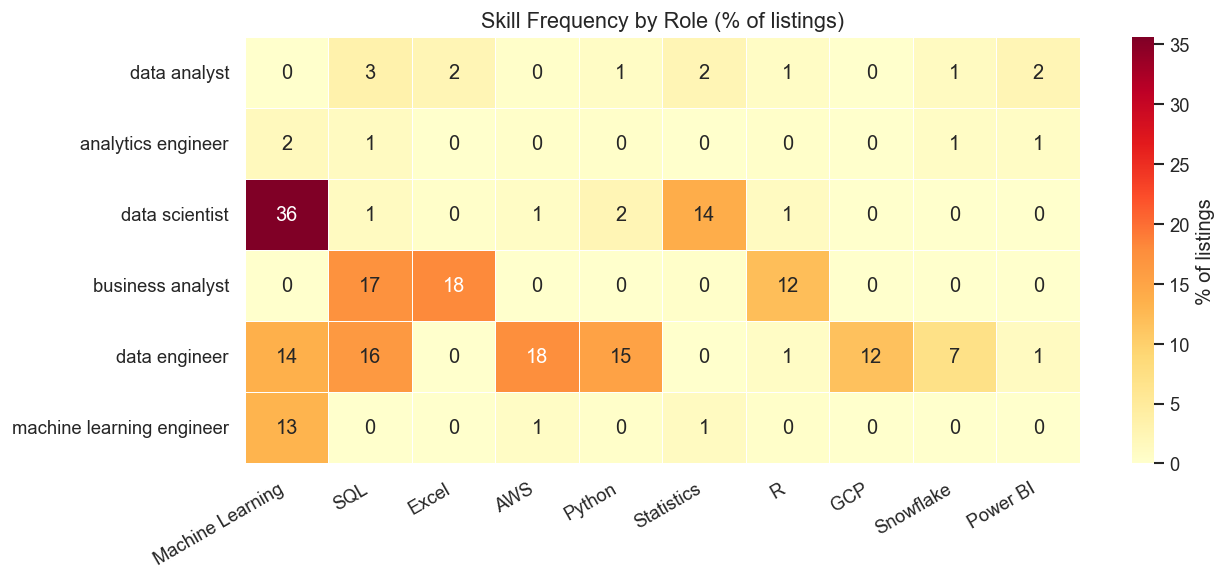

In [24]:
# Skills breakdown by role
top10_skills = skills_df.head(10).index.tolist()

role_skill_matrix = {}
for role in df['search_role'].unique():
    role_desc = df[df['search_role'] == role]['description'].fillna('').str.lower()
    role_skill_matrix[role] = {
        skill: role_desc.str.contains(SKILLS[skill], regex=True).mean() * 100
        for skill in top10_skills
    }

heatmap_df = pd.DataFrame(role_skill_matrix).T

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '% of listings'}
)
ax.set_title('Skill Frequency by Role (% of listings)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Salary Analysis

In [25]:
salary_df = df[df['salary_min'].notna() & df['salary_max'].notna()].copy()
salary_df['salary_mid'] = (salary_df['salary_min'] + salary_df['salary_max']) / 2

# Remove obvious outliers (hourly rates entered as annual, <$20k or >$500k)
salary_df = salary_df[(salary_df['salary_mid'] >= 20_000) & (salary_df['salary_mid'] <= 500_000)]

print(f'Listings with valid salary data: {len(salary_df):,} ({len(salary_df)/len(df):.1%} of total)')
print()
print(salary_df.groupby('search_role')['salary_mid'].describe()[['count','mean','50%','min','max']]
      .sort_values('mean', ascending=False)
      .rename(columns={'50%': 'median'})
      .map(lambda x: f'${x:,.0f}' if isinstance(x, float) else x))

Listings with valid salary data: 1,499 (100.0% of total)

                          count      mean    median      min       max
search_role                                                           
data scientist             $250  $149,286  $146,188  $71,718  $369,879
analytics engineer         $249  $139,267  $130,706  $49,642  $411,340
data engineer              $250  $135,470  $128,790  $48,912  $282,773
machine learning engineer  $250  $106,050   $89,313  $76,925  $439,562
data analyst               $250   $98,828   $97,422  $21,108  $216,649
business analyst           $250   $97,039   $91,473  $40,860  $238,278


C:\Users\faafm\AppData\Local\Temp\ipykernel_4368\3704733178.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


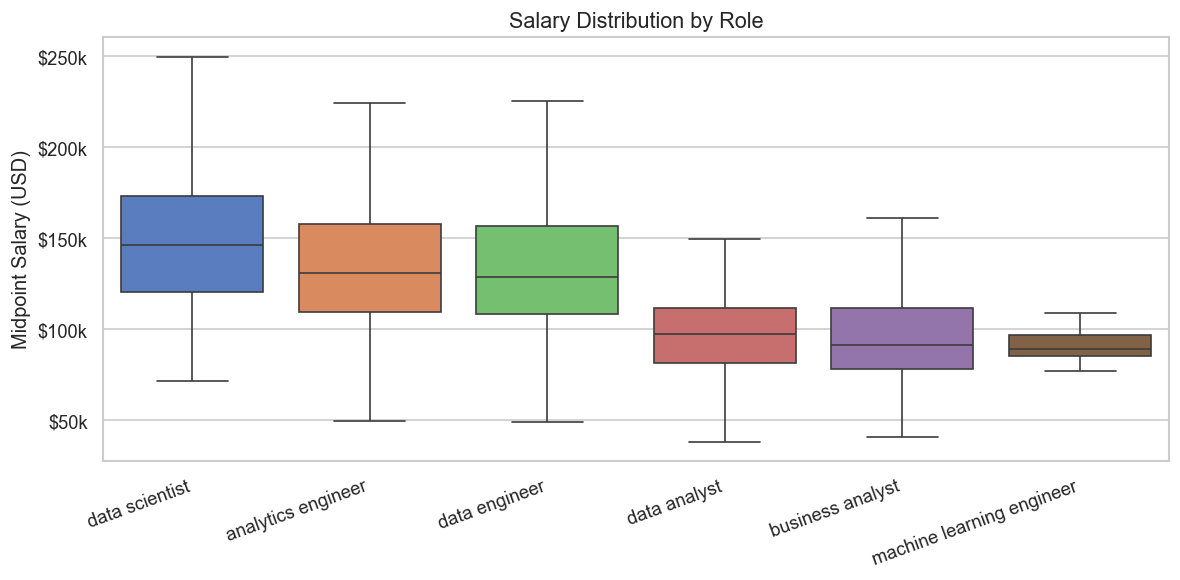

In [26]:
role_order = salary_df.groupby('search_role')['salary_mid'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=salary_df,
    x='search_role', y='salary_mid',
    order=role_order,
    palette='muted', ax=ax,
    showfliers=False
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('')
ax.set_ylabel('Midpoint Salary (USD)')
ax.set_title('Salary Distribution by Role', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

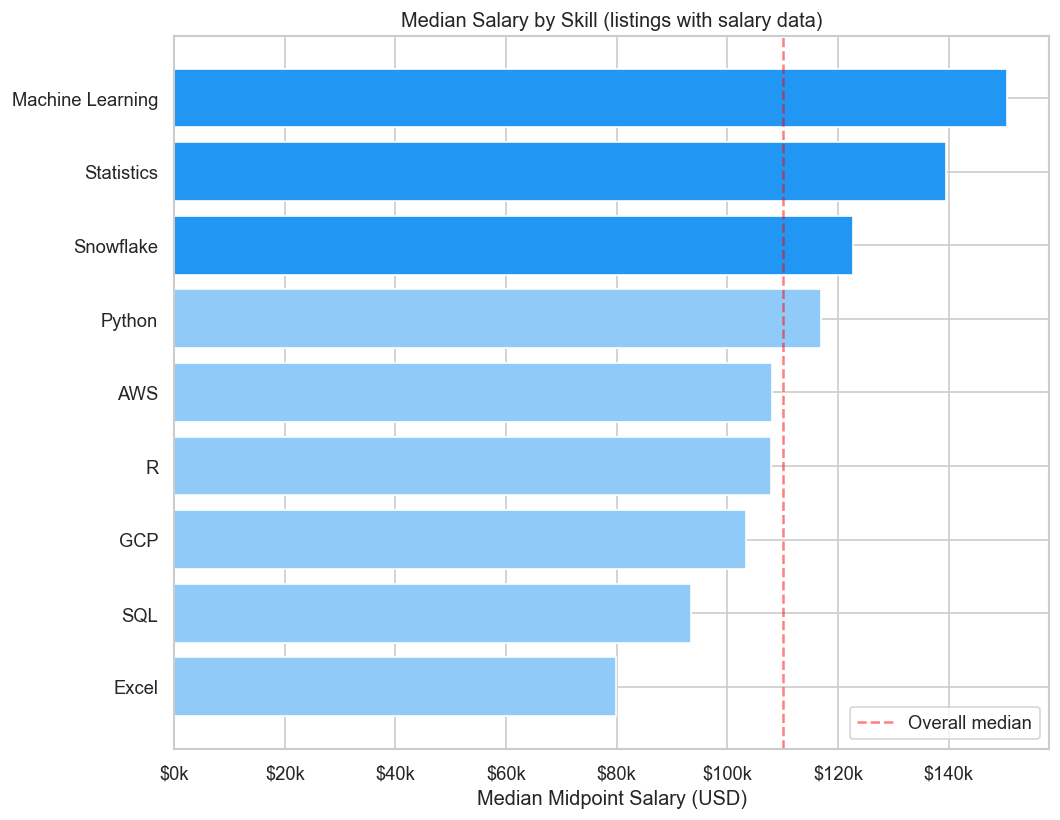

In [27]:
# Salary vs key skills (for all roles combined)
skill_salary = {}
for skill, pattern in SKILLS.items():
    has_skill = salary_df['description'].fillna('').str.lower().str.contains(pattern, regex=True)
    if has_skill.sum() >= 20:  # only include skills with enough data
        skill_salary[skill] = {
            'median_salary': salary_df[has_skill]['salary_mid'].median(),
            'count': has_skill.sum()
        }

skill_sal_df = pd.DataFrame(skill_salary).T.sort_values('median_salary', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2196F3' if s >= 120_000 else '#90CAF9' for s in skill_sal_df['median_salary']]
bars = ax.barh(skill_sal_df.index[::-1], skill_sal_df['median_salary'][::-1], color=colors[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Median Salary by Skill (listings with salary data)', fontsize=12)
ax.set_xlabel('Median Midpoint Salary (USD)')
ax.axvline(salary_df['salary_mid'].median(), color='red', linestyle='--', alpha=0.5, label=f'Overall median')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Location & Remote Opportunities
Identifying remote-friendly positions — the most relevant for working internationally.

In [28]:
# Detect remote mentions across title, location, and description
remote_pattern = r'\bremote\b|\bwork\s+from\s+home\b|\bwfh\b|\bfully\s+remote\b|\bhybrid\b'

df['is_remote'] = (
    df['title'].fillna('').str.lower().str.contains(remote_pattern, regex=True) |
    df['location_display'].fillna('').str.lower().str.contains(remote_pattern, regex=True) |
    df['description'].fillna('').str.lower().str.contains(remote_pattern, regex=True)
)

# Distinguish fully remote vs hybrid
df['is_fully_remote'] = (
    df['title'].fillna('').str.lower().str.contains(r'\bfully\s+remote\b|\b100%\s+remote\b', regex=True) |
    df['location_display'].fillna('').str.lower().str.contains(r'\bremote\b', regex=True) |
    df['description'].fillna('').str.lower().str.contains(r'\bfully\s+remote\b|\b100%\s+remote\b', regex=True)
)

df['is_hybrid'] = (
    df['description'].fillna('').str.lower().str.contains(r'\bhybrid\b', regex=True) & ~df['is_fully_remote']
)

print(f'Total listings:         {len(df):,}')
print(f'Any remote mention:     {df["is_remote"].sum():,} ({df["is_remote"].mean():.1%})')
print(f'Fully remote:           {df["is_fully_remote"].sum():,} ({df["is_fully_remote"].mean():.1%})')
print(f'Hybrid:                 {df["is_hybrid"].sum():,} ({df["is_hybrid"].mean():.1%})')
print(f'On-site only (no mention): {(~df["is_remote"]).sum():,} ({(~df["is_remote"]).mean():.1%})')

Total listings:         1,499
Any remote mention:     211 (14.1%)
Fully remote:           95 (6.3%)
Hybrid:                 65 (4.3%)
On-site only (no mention): 1,288 (85.9%)


In [29]:
# Remote rate by role
remote_by_role = df.groupby('search_role').agg(
    total=('id', 'count'),
    remote=('is_remote', 'sum'),
    fully_remote=('is_fully_remote', 'sum'),
    hybrid=('is_hybrid', 'sum'),
).assign(
    remote_pct=lambda x: x['remote'] / x['total'] * 100,
    fully_remote_pct=lambda x: x['fully_remote'] / x['total'] * 100,
).sort_values('remote_pct', ascending=False)

print(remote_by_role[['total','remote','fully_remote','hybrid','remote_pct','fully_remote_pct']].to_string())

                           total  remote  fully_remote  hybrid  remote_pct  fully_remote_pct
search_role                                                                                 
business analyst             250      92            62       5   36.800000         24.800000
data analyst                 250      47            27      13   18.800000         10.800000
analytics engineer           249      25             3      18   10.040161          1.204819
data engineer                250      25             3      15   10.000000          1.200000
data scientist               250      20             0      12    8.000000          0.000000
machine learning engineer    250       2             0       2    0.800000          0.000000


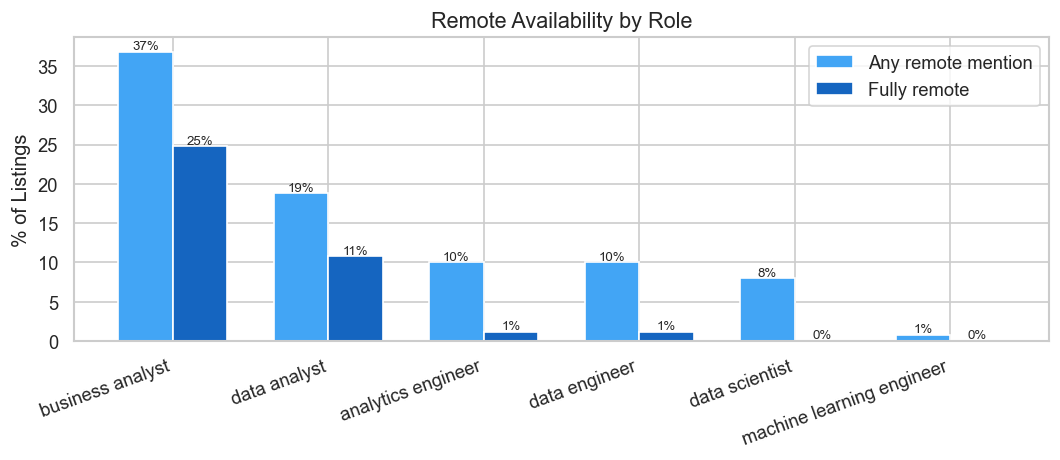

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(remote_by_role))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], remote_by_role['remote_pct'], width,
               label='Any remote mention', color='#42A5F5')
bars2 = ax.bar([i + width/2 for i in x], remote_by_role['fully_remote_pct'], width,
               label='Fully remote', color='#1565C0')

ax.set_xticks(x)
ax.set_xticklabels(remote_by_role.index, rotation=20, ha='right')
ax.set_ylabel('% of Listings')
ax.set_title('Remote Availability by Role', fontsize=13)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.0f}%', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

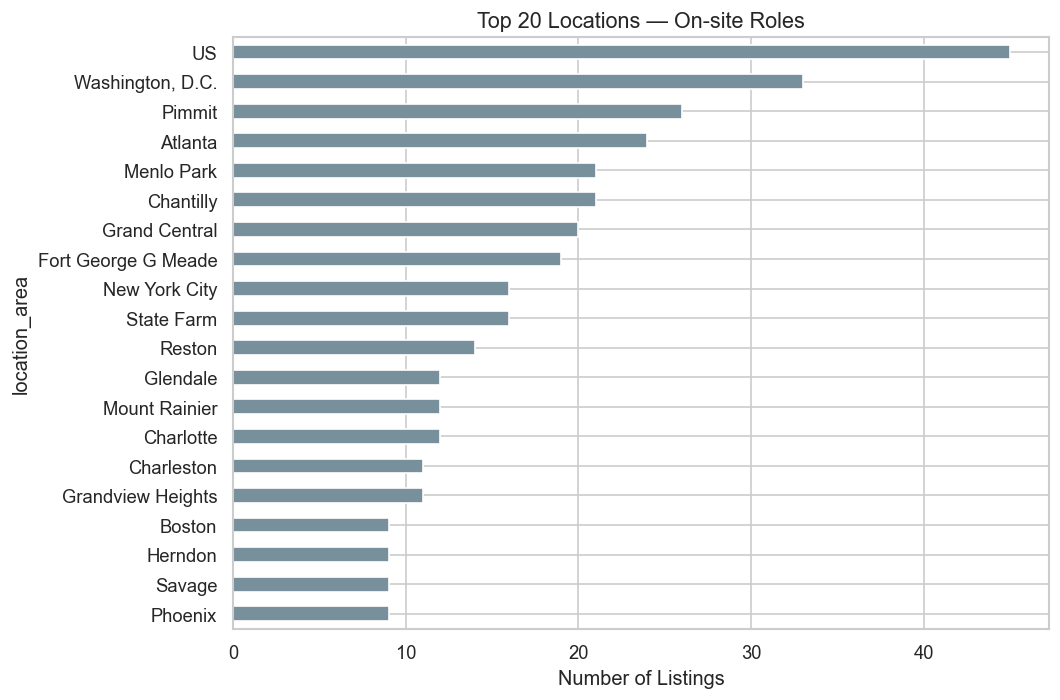

In [31]:
# Top locations for on-site/in-person roles (to understand where the market is concentrated)
onsite = df[~df['is_remote']].copy()

# Extract state from location_area (Adzuna returns city or state level)
state_counts = onsite['location_area'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
state_counts[::-1].plot(kind='barh', ax=ax, color='#78909C')
ax.set_xlabel('Number of Listings')
ax.set_title('Top 20 Locations — On-site Roles', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Fully remote listings — what do they look like?
remote_listings = df[df['is_fully_remote']].copy()
print(f'Fully remote listings: {len(remote_listings)}')
print()
print('Remote listings by role:')
print(remote_listings['search_role'].value_counts().to_string())
print()
print('Sample remote job titles:')
print(remote_listings['title'].sample(min(10, len(remote_listings)), random_state=42).tolist())

Fully remote listings: 95

Remote listings by role:
search_role
business analyst      62
data analyst          27
data engineer          3
analytics engineer     3

Sample remote job titles:
['Business Analyst', 'Data Analyst (Remote)', 'Business Analyst', 'Business Analyst', 'Data Analyst', 'Data Analyst (Remote)', 'Business Analyst', 'Business Analyst', 'Data Analyst (Remote)', 'Business Analyst']


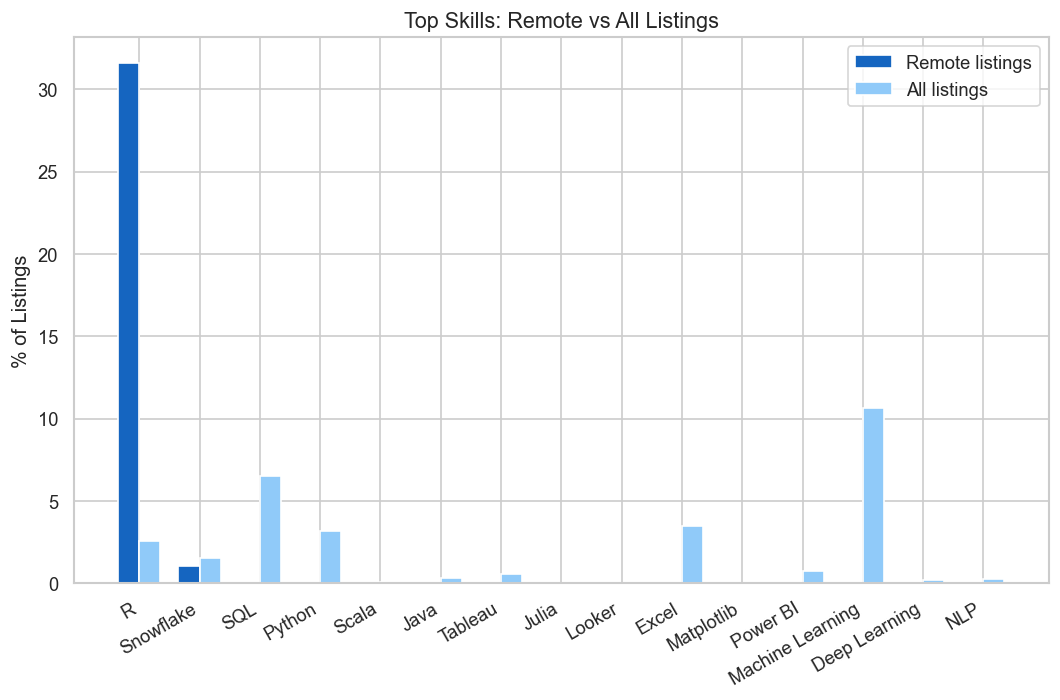

In [33]:
# Skills most in demand in remote listings specifically
remote_desc = remote_listings['description'].fillna('').str.lower()

remote_skill_pct = {}
for skill, pattern in SKILLS.items():
    if len(remote_listings) > 0:
        remote_skill_pct[skill] = remote_desc.str.contains(pattern, regex=True).mean() * 100

remote_skills_series = pd.Series(remote_skill_pct).sort_values(ascending=False).head(15)

# Compare remote vs overall
comparison = pd.DataFrame({
    'Remote': remote_skills_series,
    'All listings': pd.Series({s: desc.str.contains(SKILLS[s], regex=True).mean() * 100
                               for s in remote_skills_series.index})
})

fig, ax = plt.subplots(figsize=(9, 6))
x = range(len(comparison))
width = 0.35
ax.bar([i - width/2 for i in x], comparison['Remote'], width, label='Remote listings', color='#1565C0')
ax.bar([i + width/2 for i in x], comparison['All listings'], width, label='All listings', color='#90CAF9')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_ylabel('% of Listings')
ax.set_title('Top Skills: Remote vs All Listings', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

Median salary by work mode:
             median_salary   count
work_mode                         
Hybrid            $122,772     $65
On-site           $111,712  $1,339
Fully Remote       $95,494     $95


C:\Users\faafm\AppData\Local\Temp\ipykernel_4368\2687669466.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f'${x:,.0f}' if isinstance(x, (int, float)) else x))
C:\Users\faafm\AppData\Local\Temp\ipykernel_4368\2687669466.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


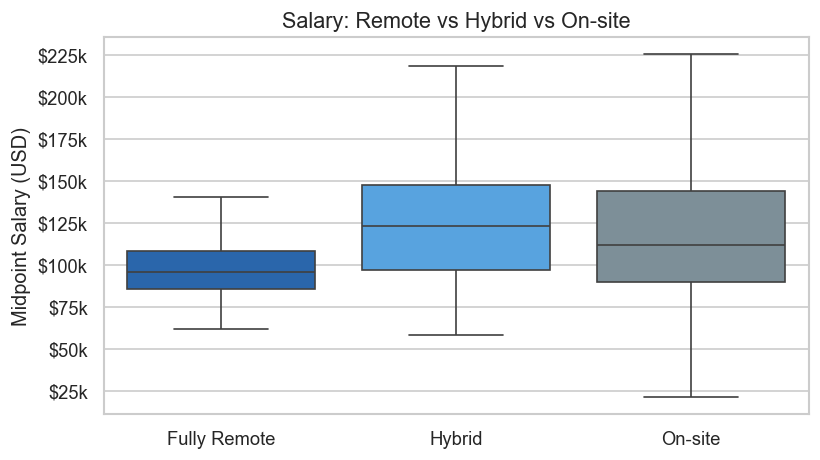

In [34]:
# Salary: remote vs on-site
salary_remote = salary_df.copy()
salary_remote['work_mode'] = salary_remote['description'].fillna('').str.lower().apply(
    lambda x: 'Fully Remote' if re.search(r'\bfully\s+remote\b|\b100%\s+remote\b', x)
    else ('Hybrid' if re.search(r'\bhybrid\b', x)
    else 'On-site')
)

print('Median salary by work mode:')
print(salary_remote.groupby('work_mode')['salary_mid'].agg(['median','count'])
      .rename(columns={'median': 'median_salary'})
      .sort_values('median_salary', ascending=False)
      .applymap(lambda x: f'${x:,.0f}' if isinstance(x, (int, float)) else x))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=salary_remote,
    x='work_mode', y='salary_mid',
    order=['Fully Remote', 'Hybrid', 'On-site'],
    palette=['#1565C0', '#42A5F5', '#78909C'],
    showfliers=False, ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('')
ax.set_ylabel('Midpoint Salary (USD)')
ax.set_title('Salary: Remote vs Hybrid vs On-site', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Key Takeaways

*(Fill in after running — summarize what the data shows)*

**Skills to prioritize:**  
- ...

**Salary expectations:**  
- ...

**Remote opportunity:**  
- ...

**Best roles to target as a Chilean applicant:**  
- ...